## 1. Overview of PCA

**PCA (Principal Component Analysis)** is an Unsupervised Learning algorithm primarily used for dimensionality reduction.
- **The Core Goal:** Find a new coordinate system (the Principal Components) to project high-dimensional data into a lower-dimensional space.
- **The Optimization Logic:** It achieves this by **maximizing variance** (keeping the most spread-out, informative data) and **minimizing reconstruction error** (ensuring the new data points stay as close to the originals as possible).
- **The Result:** It transforms a set of correlated variables into a new set of completely **linearly independent** (uncorrelated) variables.

## 2. How PCA Works

From a linear algebra perspective, here is the step-by-step pipeline:
- **Step 1 Mean Centering & Scaling:**
  - **The Math:**
  $$
  X_{scaled} = \frac{X - \mu}{\sigma}
  $$ 
  - **The Purpose:** PCA is strictly variance-driven and highly sensitive to data scales. If you don't scale the data, a feature with a massive numerical range (e.g., house prices in billions) will completely swallow a feature with a small range (e.g., number of rooms), tricking PCA into thinking the larger feature is the only important Principal Component. Scaling forces all features to compete on an equal playing field. Centering shifts the data cloud to the origin $(0,0)$ so the algorithm can accurately measure the spread around the center.
- **Step 2 The Covariance Matrix**
  - **The Math:**
  $$
  \Sigma = \frac{1}{n-1} X^T X
  $$
  - **The Purpose:** To map out the structural relationship of the entire dataset. The diagonal elements of $\Sigma$ quantify the variance (information volume) of individual features, while the off-diagonal elements measure the correlation (information redundancy) between feature pairs. PCA needs this "map" to identify overlapping patterns so it can eliminate them.
- **Step 3 Eigendecomposition / SVD**
  - **The Math:** Solve $\Sigma v = \lambda v$ (or use the computationally safer $X = U \Sigma V^T$)
  - **The Purpose:** This is the mathematical engine of PCA. It extracts the absolute core geometric directions of the data.
    - **Eigenvectors ($V^T$):** These create your new coordinate axes. The math guarantees they are perfectly orthogonal (perpendicular), meaning your new features will have absolutely zero correlation with one another.
    - **Eigenvalues ($\lambda$):** This is the built-in scoring system. It tells you exactly how much variance (valuable information) is captured by each corresponding eigenvector.
- **Step 4 Sorting & Selection**
  - **The Math:** Rank the eigenvalues in descending order ($\lambda_1 \ge \lambda_2 \dots$). Keep the top $k$ corresponding eigenvectors to form your projection weight matrix $W$.
  - **The Purpose:** This is where the actual "dimensionality reduction" and "denoising" occur. By discarding the eigenvectors with the lowest scores, you intentionally throw away the dimensions that contain the least information (which are usually just random noise), keeping only the dominant patterns.
- **Step 5 Projection**
  - **The Math:**
  $$
  Z = X_{scaled} \cdot W
  $$
  - **The Purpose:** To physically translate the data from the old, high-dimensional, and redundant coordinate system into your newly discovered, clean, and compressed $k$-dimensional space. This matrix multiplication calculates the exact new coordinates for every single data point.

## 3. End-to-End Example & Data Reconstruction

Let’s compress a small dataset of 3 samples from 2D down to 1D.
- **Original Data:** We have a matrix $X_{orig}$ with 3 samples (rows) and 2 features (columns).
  $$
  X_{orig} = 
  \begin{bmatrix} 
    12 & 14 \\ 
    8 & 6 \\ 
    10 & 10 
  \end{bmatrix}
  $$
  Let's calculate the column means. The mean for feature 1 is $(12+8+10)/3 = 10$. The mean for feature 2 is $(14+6+10)/3 = 10$. So, the mean vector is $\mu = \begin{bmatrix} 10 & 10 \end{bmatrix}$.
- **Step 1 - Centering:** Subtract the mean vector from every row in the dataset.
  $$
  X = X_{orig} - \mu = 
  \begin{bmatrix} 
    12-10 & 14-10 \\ 
    8-10 & 6-10 \\ 
    10-10 & 10-10 
    \end{bmatrix} = 
  \begin{bmatrix} 
    2 & 4 \\ 
    -2 & -4 \\ 
    0 & 0 
  \end{bmatrix}
  $$
- **Step 2 - The PCA Matrix:** Assume our math (Eigendecomposition) gave us PC1 as the weight matrix $W$ (a $2 \times 1$ matrix).
  $$
  W = 
  \begin{bmatrix}
    \frac{1}{\sqrt{2}} \\
    \frac{1}{\sqrt{2}}
  \end{bmatrix}
  $$
- **Step 3 - Forward Projection (Compression):** Multiply the entire centered dataset $X$ ($3 \times 2$) by the matrix $W$ ($2 \times 1$).
  $$
  Z = X \cdot W = 
  \begin{bmatrix} 
    2 & 4 \\
    -2 & -4 \\ 
    0 & 0 
  \end{bmatrix} 
  \begin{bmatrix} 
    \frac{1}{\sqrt{2}} \\ 
    \frac{1}{\sqrt{2}} 
  \end{bmatrix} = 
  \begin{bmatrix} 
    \frac{2}{\sqrt{2}} + \frac{4}{\sqrt{2}} \\ 
    -\frac{2}{\sqrt{2}} - \frac{4}{\sqrt{2}} \\ 
    0 + 0 
  \end{bmatrix} = 
  \begin{bmatrix} 
    \frac{6}{\sqrt{2}} \\ 
    -\frac{6}{\sqrt{2}} \\ 
    0 
  \end{bmatrix}
  $$
  (Our entire dataset is now compressed into a $3 \times 1$ matrix. Each sample is represented by just a single number).
- **Step 4 - Inverse Transform (Reconstruction):** Multiply the compressed dataset $Z$ ($3 \times 1$) by the transpose of $W$ ($1 \times 2$) to project it back to 2D space.
  $$
  \hat{X} = Z \cdot W^T = 
  \begin{bmatrix} 
    \frac{6}{\sqrt{2}} \\ 
    -\frac{6}{\sqrt{2}} \\ 
    0 
  \end{bmatrix} 
  \begin{bmatrix} 
    \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \end{bmatrix} = 
  \begin{bmatrix} 
    3 & 3 \\ 
    -3 & -3 \\ 
    0 & 0 
  \end{bmatrix}$$
- **Step 5 - Add the Mean Back:** Add the mean vector $\mu$ back to every row of the reconstructed matrix.
  $$
  \hat{X}_{orig} = \hat{X} + \mu = 
  \begin{bmatrix} 3 & 3 \\ 
    -3 & -3 \\ 
    0 & 0 
  \end{bmatrix} + 
  \begin{bmatrix} 10 & 10 \\ 
    10 & 10 \\ 
    10 & 10 
  \end{bmatrix} = 
  \begin{bmatrix} 13 & 13 \\ 
    7 & 7 \\ 
    10 & 10 
  \end{bmatrix}
  $$
- **The Takeaway:** Let's compare the Original vs. Reconstructed data:
  - Sample 1: $\begin{bmatrix} 12 & 14 \end{bmatrix} \rightarrow \begin{bmatrix} 13 & 13 \end{bmatrix}$ (Loss: $[-1, 1]$)
  - Sample 2: $\begin{bmatrix} 8 & 6 \end{bmatrix} \rightarrow \begin{bmatrix} 7 & 7 \end{bmatrix}$ (Loss: $[1, -1]$)
  - Sample 3: $\begin{bmatrix} 10 & 10 \end{bmatrix} \rightarrow \begin{bmatrix} 10 & 10 \end{bmatrix}$ (Perfect reconstruction because it was exactly at the mean).

  The reconstructed matrix $\hat{X}_{orig}$ is slightly distorted compared to $X_{orig}$. The missing details represent the variance that was discarded when we chose to drop PC2.

## 4. Optimizing the Number of Components ($K$)

Choosing $K$ is a trade-off between computational efficiency and information loss. Here are three practical ways to find the sweet spot:
- **Cumulative Explained Variance:** Set a target for how much information you want to retain (e.g., 90% or 95%). Calculate the ratio $\frac{\lambda_i}{\sum \lambda}$ and keep adding PCs until you hit that threshold.
- **The Elbow Method (Scree Plot):** Plot the variance explained by each individual PC. Look for the "elbow"—the point where the graph sharply bends and flattens out. Everything after that point is mostly just noise.
- **Cross-Validation in a Pipeline:** Treat $K$ as a model hyperparameter. Test different values ($K = 10, 20, 30 \dots$) and see which one yields the highest accuracy for your downstream ML model (like a Random Forest or SVM).

## 5. Crucial Caveats & Best Practices
- **Always Scale Your Data:** Features with large numbers will dominate PCA. Use **StandardScaler** first. And remember the golden rule of data pipelines: **always split your train and test sets before scaling** to avoid data leakage!
- **Beware of Outliers:** Because PCA relies on squared distances, it is highly sensitive to anomalies. Clean your outliers during the EDA phase, or switch to **Robust PCA** if the noise is too complex.
- **The Sparse Data Trap:** NEVER use standard PCA on sparse matrices (like TF-IDF text data). The mean centering step will turn millions of zeros into non-zeros, instantly blowing up your RAM. Use Truncated SVD instead.

## 6. Pros & Cons of PCA

**Pros:**
- **Resource Efficiency:** Massively reduces computational cost and memory usage.
- **Built-in Denoising:** By dropping the trailing PCs, you naturally filter out random noise from the dataset.
- **Tackles Multicollinearity:** The new PCs are completely uncorrelated, making models like Linear Regression much more stable.
- **Data Visualization:** It allows you to squash thousands of dimensions down to 2D or 3D so you can visually inspect your data clusters.

**Cons:**
- **Loss of Interpretability:** The new PCs are abstract math equations, not real-world features. You can't easily explain to stakeholders what "PC1" actually means in business terms.
- **Information Loss:** You always lose some variance, which might accidentally erase important signals, especially for classifying rare events.
- **The Linear Blind Spot:** PCA only understands straight lines and flat planes. If your data is tangled or rolled up (like a Swiss Roll), PCA will fail. You'll need manifold learning techniques like **Kernel PCA**, **t-SNE**, or **UMAP** to handle non-linear patterns.

## Implement PCA from scratch

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [2]:
class PCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.mean = None
        self.components = None
        self.explained_variance_ = None
    
    def fit(self, X):
        """
        Fit the PCA model to the data X.
        Parameters:
        X : array-like, shape (n_samples, n_features)
        
        """
        # Center the data
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        # Compute the covariance matrix
        covariance_matrix = np.cov(X_centered, rowvar=False)

        # Compute the eigenvalues and eigenvectors
        eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

        # Sort the eigenvalues and eigenvectors
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        # Store the principal components and explained variance
        self.components = eigenvectors[:, :self.n_components].T
        self.explained_variance_ = eigenvalues[:self.n_components]

    def transform(self, X):
        X_centered = X - self.mean
        return np.dot(X_centered, self.components.T)
    
    @property
    def explained_variance_ratio_(self):
        total_variance = np.sum(self.explained_variance_)
        return self.explained_variance_ / total_variance
    
    def inverse_transform(self, X_transformed):
        return np.dot(X_transformed, self.components) + self.mean

In [3]:
data = load_iris()
X = data.data
y = data.target

In [4]:
X[:5, :]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [5]:
y[:5]

array([0, 0, 0, 0, 0])

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
pca = PCA(n_components=2)
pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)

In [8]:
print("Shape of original data:", X.shape)
print("Shape of PCA-transformed data:", X_pca.shape)

Shape of original data: (150, 4)
Shape of PCA-transformed data: (150, 2)


In [9]:
X_pca[:5, :]

array([[ 2.26470281,  0.4800266 ],
       [ 2.08096115, -0.67413356],
       [ 2.36422905, -0.34190802],
       [ 2.29938422, -0.59739451],
       [ 2.38984217,  0.64683538]])

In [10]:
print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.76150718 0.23849282]


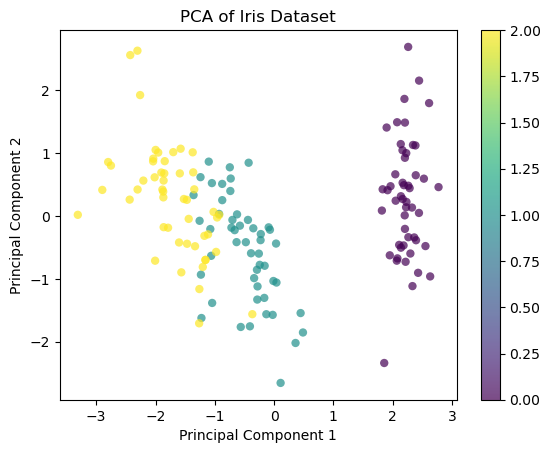

In [11]:
x1 = X_pca[:, 0]
x2 = X_pca[:, 1]

plt.scatter(x1, x2, c=y, cmap="viridis", edgecolors="none", alpha=0.7)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Iris Dataset")
plt.colorbar()
plt.show()